In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\cyber_attack_dataset_18k_v2.csv")
df

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,src_bytes,dst_bytes,traffic_volume,packet_rate,error_rate,syn_flag_count,session_count,login_risk_score,traffic_intensity,total_data_transfer,attack_detected
0,1190,TCP,3,4256,No,0.46,5,Edge,No,91210,14522,295612,326.71,0.148,17,39,0.74,90.82,28668,0
1,924,TCP,5,3406,Yes,0.55,1,Chrome,No,63113,80043,709096,339.60,0.713,23,3,0.00,55.69,970171,0
2,1358,TCP,13,812,Yes,0.31,2,Chrome,No,50374,5091,307687,890.18,0.391,25,86,0.89,63.07,680445,1
3,1194,UDP,10,362,No,0.25,0,Chrome,No,92687,3228,635899,303.12,0.296,28,28,0.16,74.90,301309,0
4,1159,TCP,10,1984,No,0.82,8,Firefox,No,22883,83844,618320,145.13,0.978,7,47,0.87,48.26,254358,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,82,TCP,9,904,Yes,0.86,9,Edge,No,82265,53288,642976,291.43,0.131,18,97,0.33,79.99,977699,1
17996,1194,TCP,5,966,Yes,0.86,6,Safari,No,68961,48116,215234,410.57,0.083,9,20,0.13,77.39,667442,0
17997,374,ICMP,10,4499,Yes,0.86,0,Chrome,No,37701,5882,55386,23.02,0.150,13,23,0.89,72.18,633731,1
17998,475,UDP,1,2067,Yes,0.19,3,Edge,No,55829,40630,742256,627.55,0.038,29,98,0.92,2.98,262341,1


In [49]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
label_encoder = LabelEncoder()

categorical_columns = ['protocol_type','browser_type', 'encryption_used', 'unusual_time_access']

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("\nCategorical features encoded successfully.")


Categorical features encoded successfully.


In [50]:
main_features = [
    'network_packet_size',
    'traffic_volume',
    'packet_rate',
    'traffic_intensity'
]
scaler = MinMaxScaler()
df[main_features] = scaler.fit_transform(df[main_features])
print(df.head())

   network_packet_size  protocol_type  login_attempts  session_duration  \
0             0.784669              1               3              4256   
1             0.599303              1               5              3406   
2             0.901742              1              13               812   
3             0.787456              2              10               362   
4             0.763066              1              10              1984   

   encryption_used  ip_reputation_score  failed_logins  browser_type  \
0                0                 0.46              5             1   
1                1                 0.55              1             0   
2                1                 0.31              2             0   
3                0                 0.25              0             0   
4                0                 0.82              8             2   

   unusual_time_access  src_bytes  dst_bytes  traffic_volume  packet_rate  \
0                    0      91210      

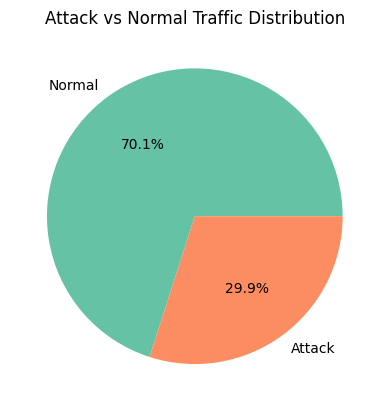

In [51]:
#What percentage of network traffic is malicious?


df['attack_detected'].value_counts().plot.pie(
    labels=['Normal', 'Attack'],   # <-- labels added
    autopct='%1.1f%%',
    colors=['#66c2a5', '#fc8d62']
)
plt.title("Attack vs Normal Traffic Distribution")
plt.ylabel("")
plt.show()

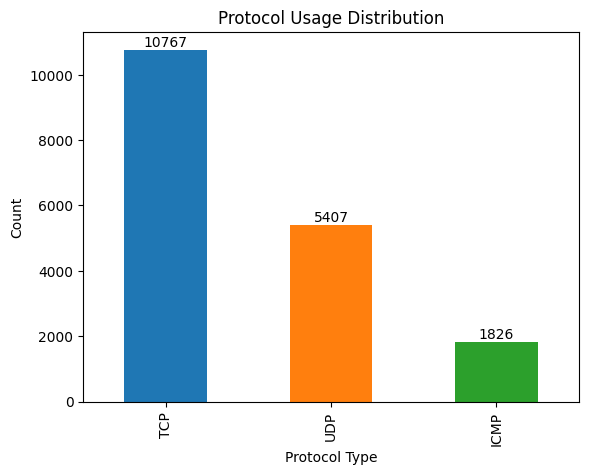

In [52]:
#Which protocol is most commonly used in the dataset?


ax = df['protocol_type'].value_counts().plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
ax.set_xticklabels(['TCP', 'UDP', 'ICMP'])
plt.title("Protocol Usage Distribution")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

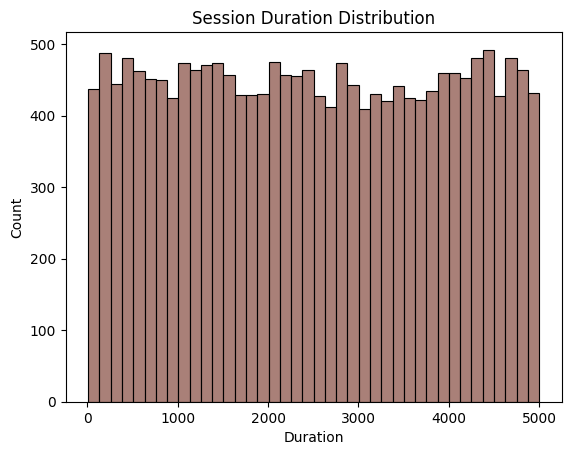

In [53]:
#Are most sessions short or long?

sns.histplot(df['session_duration'], bins=40, color='#8c564b')
plt.title("Session Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")
plt.show()

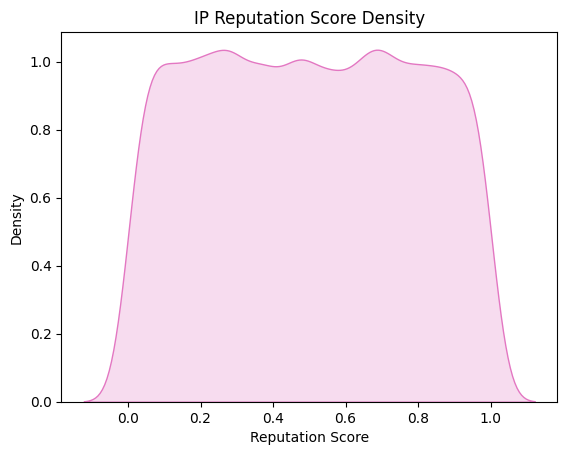

In [54]:
#Are most IPs safe or risky?

sns.kdeplot(df['ip_reputation_score'], fill=True, color='#e377c2')
plt.title("IP Reputation Score Density")
plt.xlabel("Reputation Score")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1072\3336127273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attack_detected', y='failed_logins',


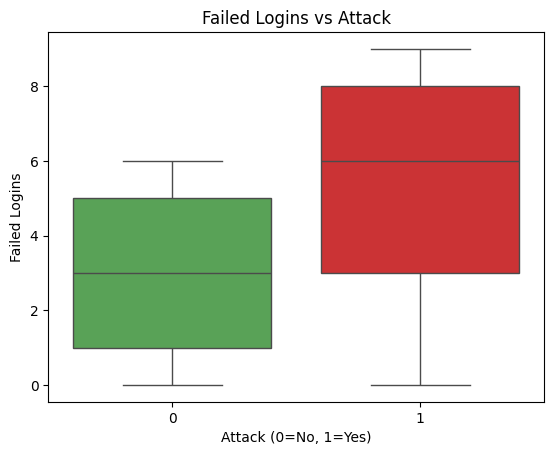

In [55]:
#Do attacks have more failed login attempts?
 
sns.boxplot(x='attack_detected', y='failed_logins', 
            data=df, palette=['#4daf4a','#e41a1c'])
plt.title("Failed Logins vs Attack")
plt.xlabel("Attack (0=No, 1=Yes)")
plt.ylabel("Failed Logins")
plt.show()

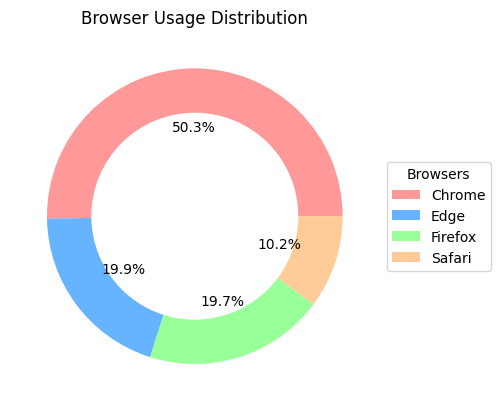

In [57]:
#Which browser is most commonly used?
 
counts = df['browser_type'].map(browser_map).value_counts()

plt.pie(
    counts,
    autopct='%1.1f%%',
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)

plt.legend(
    labels=counts.index,
    title="Browsers",
    loc="center left",
    bbox_to_anchor=(1, 0.5)   # moves legend to left/right side
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Browser Usage Distribution")
plt.show()

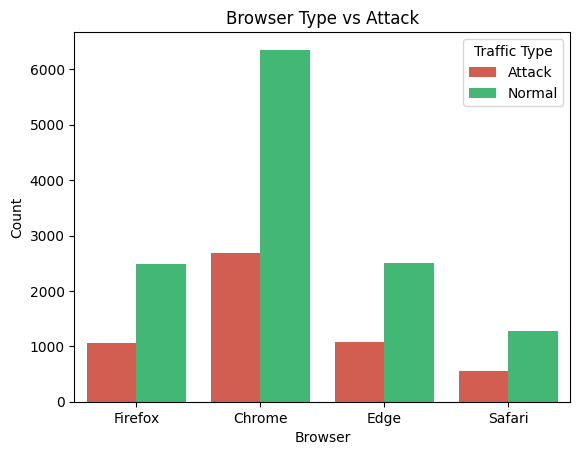

In [56]:
#Which browser is more associated with attacks?
 
browser_map = {
    0: 'Chrome',
    1: 'Firefox',
    2: 'Edge',
    3: 'Safari'
}

attack_map = {0: 'Attack', 1: 'Normal'}   # or swap if needed

df['browser_name'] = df['browser_type'].map(browser_map)
df['attack_label'] = df['attack_detected'].map(attack_map)
sns.countplot(
    x='browser_name',
    hue='attack_label',
    data=df,
    palette={'Attack': '#e74c3c', 'Normal': '#2ecc71'}
)

plt.title("Browser Type vs Attack")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.legend(title="Traffic Type")
plt.show()

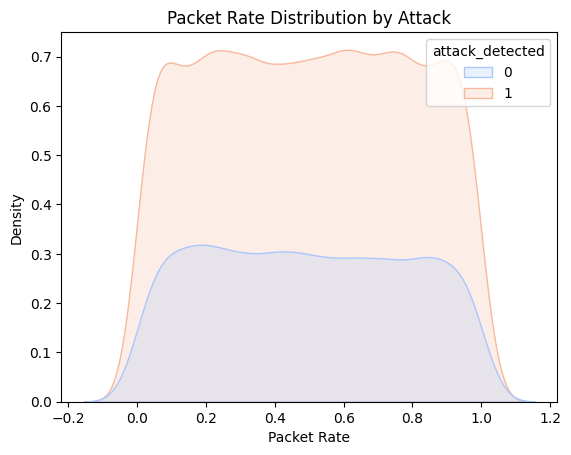

In [63]:
#Does packet rate differ between attack and normal?
 
sns.kdeplot(data=df, x='packet_rate', hue='attack_detected', 
            fill=True, palette='coolwarm')
plt.title("Packet Rate Distribution by Attack")
plt.xlabel("Packet Rate")
plt.show()

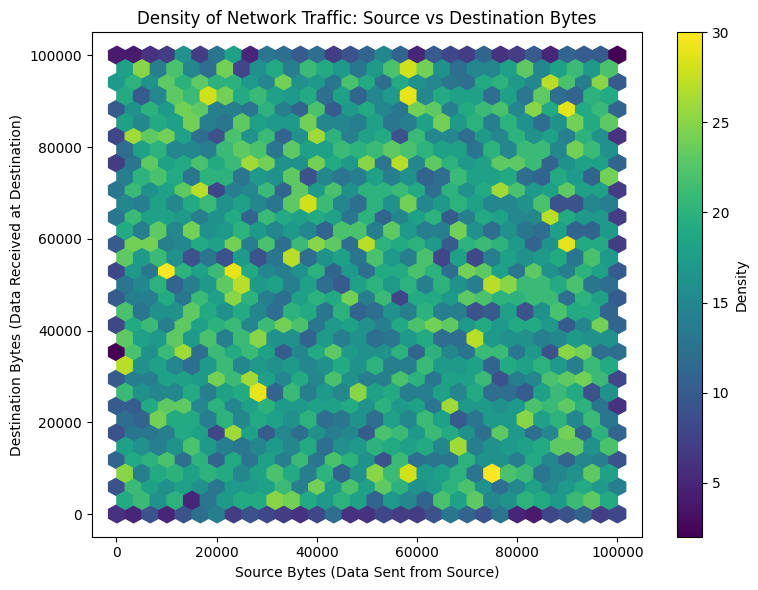

In [67]:
#Which color region in the plot shows the highest network traffic density?
 
plt.figure(figsize=(8,6))

hb = plt.hexbin(df['src_bytes'], df['dst_bytes'], 
                gridsize=30, cmap='viridis')

plt.colorbar(hb, label='Density')

plt.title("Density of Network Traffic: Source vs Destination Bytes")
plt.xlabel("Source Bytes (Data Sent from Source)")
plt.ylabel("Destination Bytes (Data Received at Destination)")

plt.tight_layout()
plt.show()

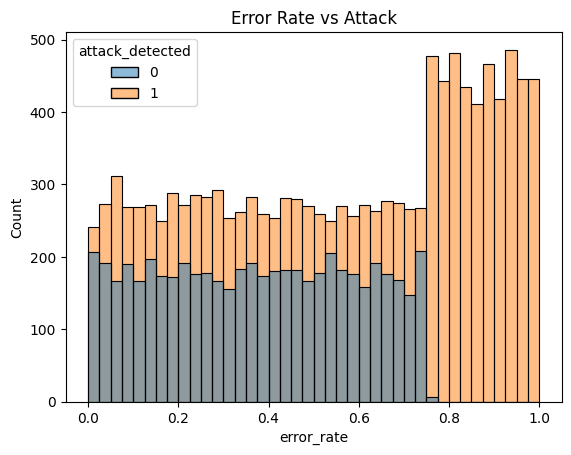

In [85]:
#How does the error rate differ between normal and attack traffic?

sns.histplot(data=df, x='error_rate', hue='attack_detected', bins=40)
plt.title("Error Rate vs Attack")
plt.show()

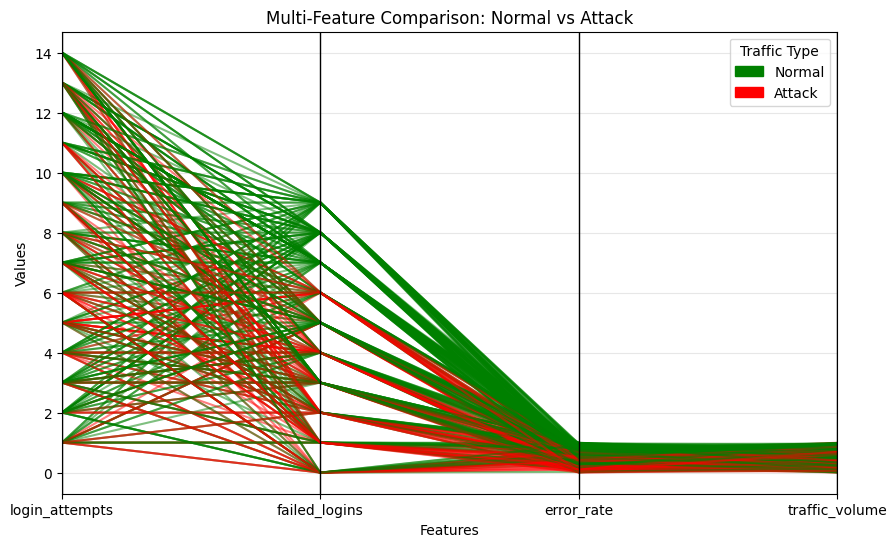

In [77]:
#How do multiple features differ between normal and attack traffic?
 
from pandas.plotting import parallel_coordinates
import matplotlib.patches as mpatches

sample = df[['login_attempts','failed_logins','error_rate',
             'traffic_volume','attack_detected']].sample(400)

sample['attack_detected'] = sample['attack_detected'].map({0:'Normal', 1:'Attack'})

plt.figure(figsize=(10,6))

# Order matters: ['Normal','Attack'] → [green, red]
parallel_coordinates(sample, 'attack_detected',
                     color=['green', 'red'], alpha=0.5)

plt.title("Multi-Feature Comparison: Normal vs Attack")
plt.xlabel("Features")
plt.ylabel("Values")

normal_patch = mpatches.Patch(color='green', label='Normal')
attack_patch = mpatches.Patch(color='red', label='Attack')

plt.legend(handles=[normal_patch, attack_patch], title="Traffic Type")

plt.grid(alpha=0.3)
plt.show()

In [84]:
#How are different browser types involved in network traffic across protocols and attacks?
 
import plotly.express as px

fig = px.sunburst(df, 
                 path=['protocol_type', 'browser_type', 'attack_detected'],
                 title="Hierarchy of Protocol → Browser → Attack")
fig.show()

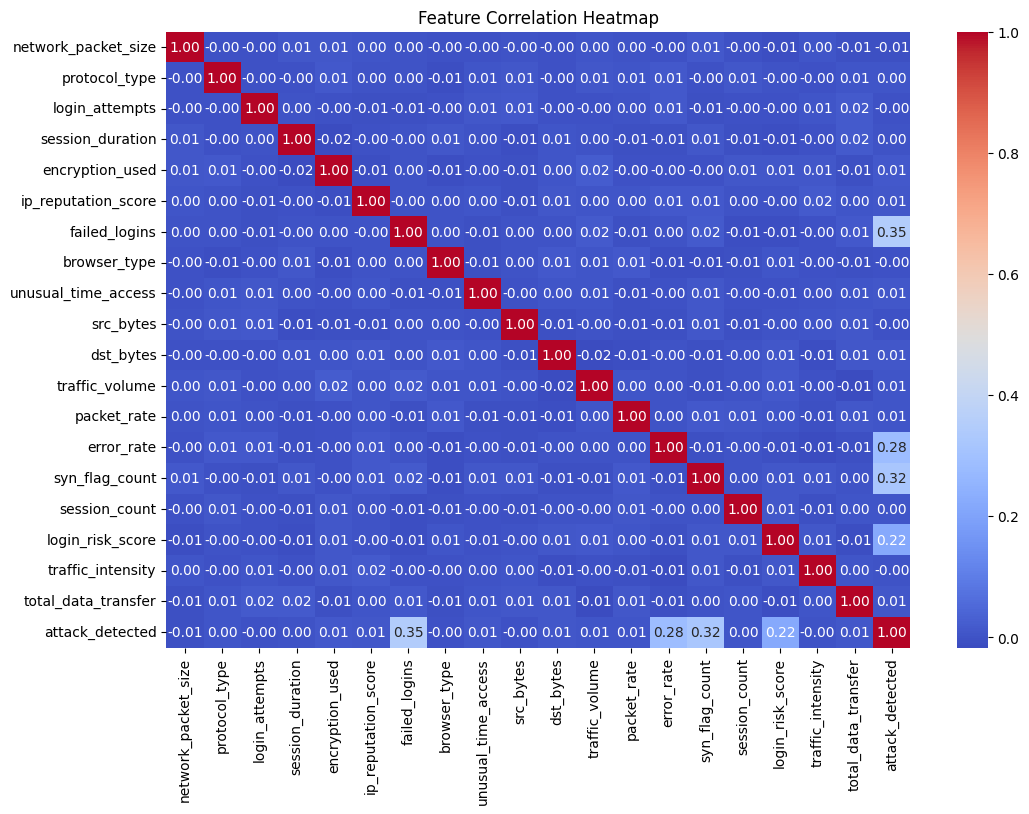

In [88]:
#Which features show the strongest positive and negative correlations in the dataset?

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [92]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Convert categorical to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop("attack_detected", axis=1)
y = df_encoded["attack_detected"]

# Train model
model = RandomForestClassifier()
model.fit(X, y)

# Get importance
importance = pd.Series(model.feature_importances_, index=X.columns)

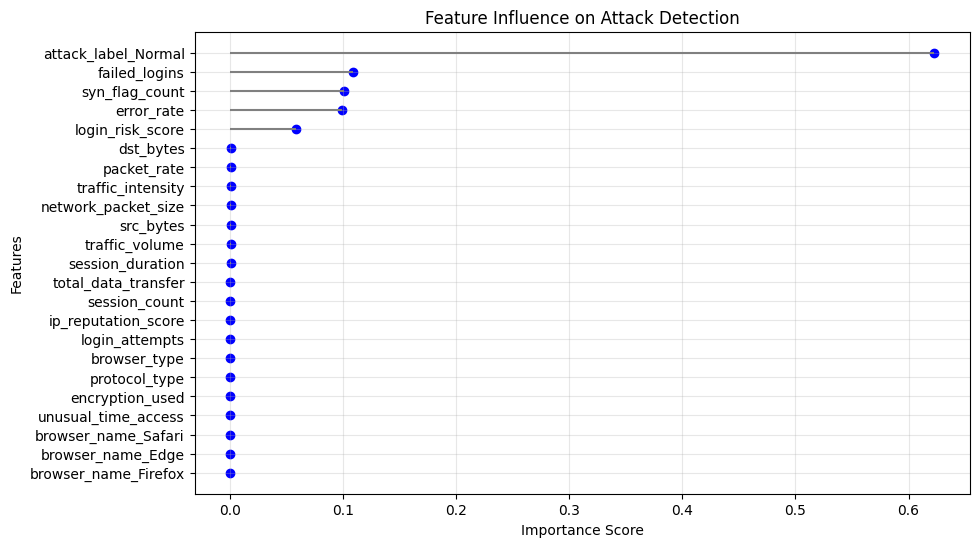

In [94]:
#Which features contribute the most to detecting cyber attacks?

importance = importance.sort_values()
plt.figure(figsize=(10,6))
plt.hlines(y=importance.index, xmin=0, xmax=importance.values, color='gray')
plt.scatter(importance.values, importance.index, color='blue')
plt.title("Feature Influence on Attack Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(alpha=0.3)
plt.show()